In [85]:
#import Library and load dataset
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\kulde\Downloads\customer_shopping_behavior.csv")

In [86]:
#data exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [87]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [70]:
df.shape

(3900, 18)

In [88]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [89]:
#Data cleaning
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [90]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ","_")

In [91]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [92]:
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [93]:
df['review_rating']=df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))

In [94]:
#Creating a new Column
frequency_mapping={
    'Fortnightly':14,
    'Weekly':7,
    'Annually':365,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Every 3 Months':90,
    'Monthly':30
}
df["Purchase_Frequency_Days"]=df['frequency_of_purchases'].map(frequency_mapping)

In [95]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [96]:
df[['Purchase_Frequency_Days','frequency_of_purchases']].head(10)

,Purchase_Frequency_Days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [97]:
df=df.drop('promo_code_used', axis=1)

In [98]:
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'Purchase_Frequency_Days'],
      dtype='str')

In [99]:
df.shape

(3900, 18)

In [100]:
import urllib
from sqlalchemy import create_engine

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=YOUR_SERVER_NAME;"
    "DATABASE=Customer_Shopping;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
## Export to SQL Server

# cleaning and transforming the dataset, it is exported to SQL Server using SQLAlchemy for further querying and analysis.

In [101]:
df.shape

(3900, 18)

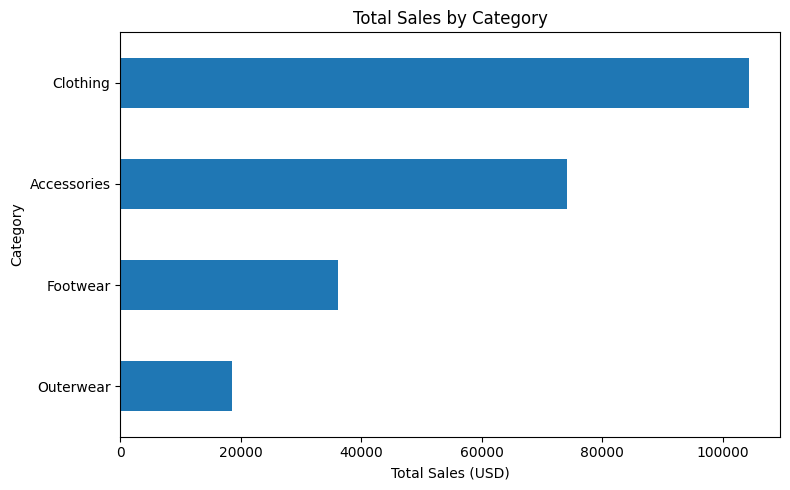

In [102]:
import matplotlib.pyplot as plt

sales = df.groupby("category")["purchase_amount"].sum().sort_values()

plt.figure(figsize=(8,5))
sales.plot(kind="barh")
plt.title("Total Sales by Category")
plt.xlabel("Total Sales (USD)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

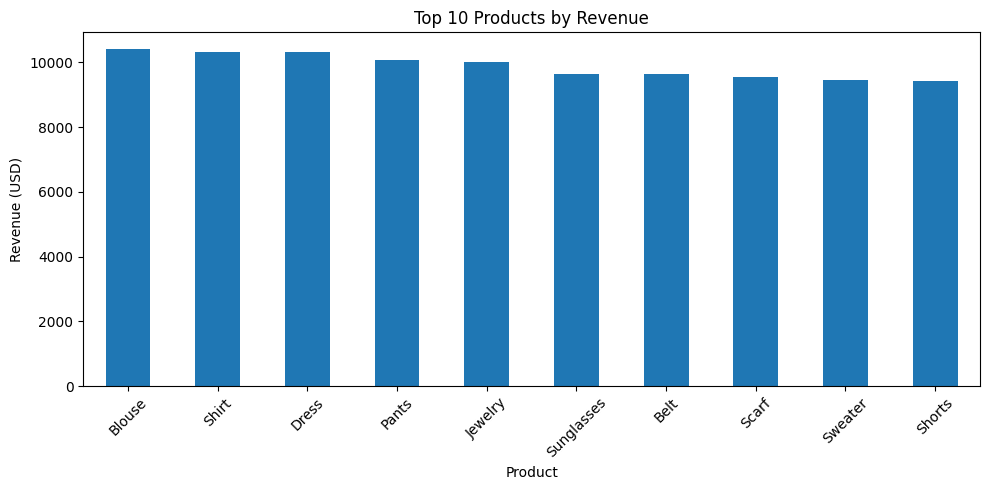

In [103]:
top_products = (
    df.groupby("item_purchased")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

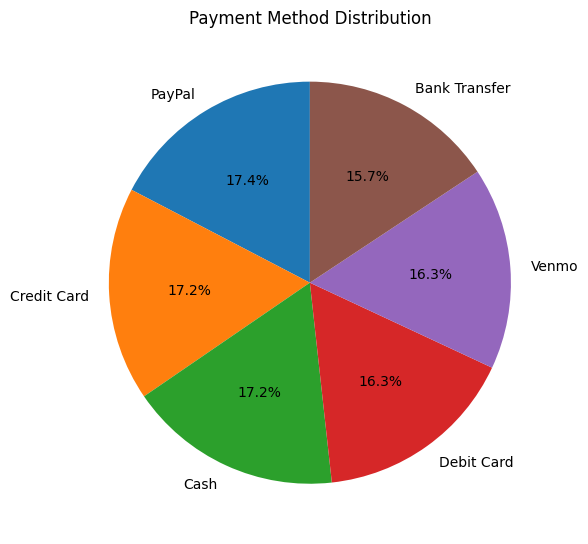

In [104]:
payment = df["payment_method"].value_counts()

plt.figure(figsize=(6,6))
payment.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

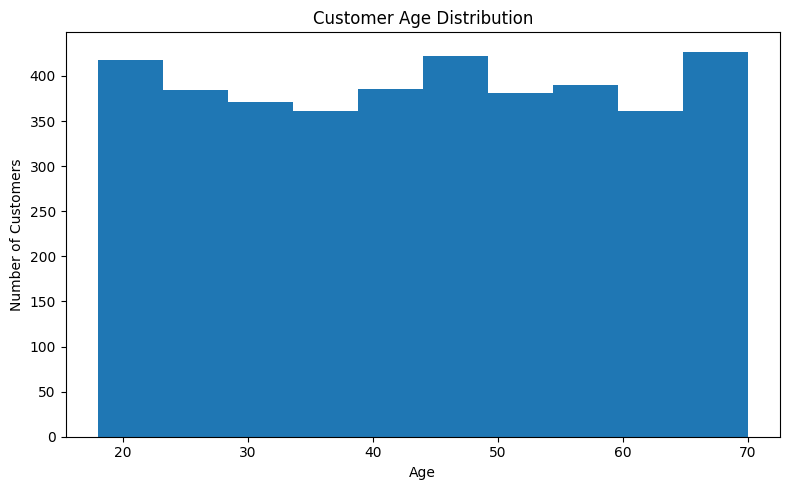

In [105]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=10)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
# Key Business Insights
- Missing review ratings were handled using the median rating within each product category.
- Purchase frequency was converted into numerical values to enable further analysis.
- Column names were standardized for consistency and easier querying.
- Redundant columns were removed after feature engineering.
- The cleaned dataset was successfully exported to SQL Server for downstream analysis.